# 04 - 28-Day Demand Forecast (Module A)

**Business problem:** Ops plans carrier capacity and support staffing 2-4 weeks out. This
notebook delivers a 28-day daily order-volume forecast with uncertainty bounds, and
quantifies the lift over the naive rule of thumb ("same as last week") via a walk-forward
backtest.

**Series:** daily count of orders PLACED (all statuses - ops must process every order
regardless of eventual outcome), over the stable window derived in `01_eda.ipynb`:
`2017-01-05` to `2018-08-22` (595 days, zero gaps - reused verbatim, not re-derived).

**Declared side effect:** this notebook writes `analytics.forecast_28d` and
`data/processed/forecast_28d.csv` (MASTER_DOC section 12) - the only notebook that does.

In [1]:
import sys

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from src.utils import get_engine, get_logger

engine = get_engine()
logger = get_logger("notebooks.04_demand_forecast")

STABLE_WINDOW_START = "2017-01-05"
STABLE_WINDOW_END = "2018-08-22"
H = 28
N_FOLDS = 6

In [2]:
daily = pd.read_sql(
    text(f"""
        SELECT order_purchase_timestamp::date AS d, COUNT(*) AS orders
        FROM analytics.fact_orders
        WHERE order_purchase_timestamp::date BETWEEN '{STABLE_WINDOW_START}' AND '{STABLE_WINDOW_END}'
        GROUP BY 1
        ORDER BY 1
    """),
    engine,
    parse_dates=["d"],
).set_index("d")["orders"].asfreq("D")

assert daily.notna().all(), "gap days present in the stable window - investigate before modeling"
print(f"Series: {len(daily)} days, {daily.index.min().date()} to {daily.index.max().date()}, "
      f"no gaps confirmed.")

Series: 595 days, 2017-01-05 to 2018-08-22, no gaps confirmed.


## Black Friday 2017 - event treatment decision

In [3]:
black_friday = pd.Timestamp("2017-11-24")
bf_orders = daily.loc[black_friday]
baseline_avg = daily.loc[black_friday - pd.Timedelta(days=14): black_friday - pd.Timedelta(days=1)].mean()
first_fold_start = daily.index[len(daily) - N_FOLDS * H]
days_before_first_fold = (first_fold_start - black_friday).days

print(
    f"{black_friday.date()} shows {bf_orders:.0f} orders vs. a {baseline_avg:.0f}/day baseline "
    f"in the prior 2 weeks ({bf_orders / baseline_avg:.1f}x) - the expected extreme promotional "
    f"spike.\n"
    f"The earliest walk-forward test fold starts {first_fold_start.date()} - "
    f"{days_before_first_fold} days after Black Friday, so the event sits entirely inside the "
    f"training data for every fold and never enters a held-out test window."
)

2017-11-24 shows 1176 orders vs. a 197/day baseline in the prior 2 weeks (6.0x) - the expected extreme promotional spike.
The earliest walk-forward test fold starts 2018-03-08 - 104 days after Black Friday, so the event sits entirely inside the training data for every fold and never enters a held-out test window.


**Treatment:** because the spike falls entirely in training data for every fold (computed
above), it can't distort the reported backtest accuracy. This is the "exclusion from error
windows" option (MASTER_DOC section 14), achieved by the fold placement itself rather than by
removing rows - simpler and avoids discarding real data the model can still learn seasonal
structure from.

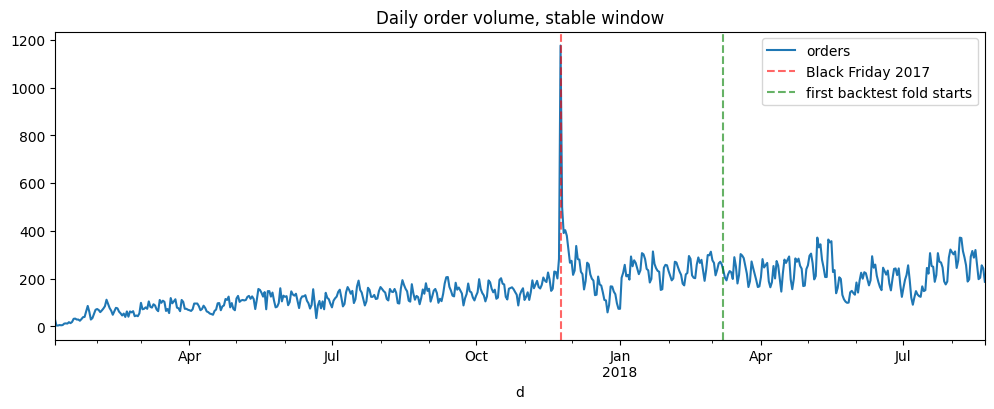

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax)
ax.axvline(pd.Timestamp("2017-11-24"), color="red", linestyle="--", alpha=0.6, label="Black Friday 2017")
ax.axvline(daily.index[len(daily) - N_FOLDS * H], color="green", linestyle="--", alpha=0.6, label="first backtest fold starts")
ax.legend()
ax.set_title("Daily order volume, stable window")
plt.show()

## Walk-forward backtest: seasonal-naive vs. Holt-Winters

In [5]:
def wape(actual: np.ndarray, forecast: np.ndarray) -> float:
    return float(np.abs(actual - forecast).sum() / np.abs(actual).sum())


def bias(actual: np.ndarray, forecast: np.ndarray) -> float:
    """Positive = over-forecasting (MASTER_DOC section 14 v2 sign convention)."""
    return float(np.mean(forecast - actual))


def seasonal_naive_forecast(train: pd.Series, horizon: int) -> np.ndarray:
    """Repeat the last observed week across the horizon."""
    last_week = train.iloc[-7:].to_numpy()
    return np.tile(last_week, horizon // 7)


def holt_winters_forecast(train: pd.Series, horizon: int) -> np.ndarray:
    model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=7).fit()
    return model.forecast(horizon).to_numpy()

In [6]:
results = []
hw_residuals = []  # pooled (actual - forecast) for the winning method's empirical intervals

for fold in range(N_FOLDS):
    test_start_idx = len(daily) - (N_FOLDS - fold) * H
    train = daily.iloc[:test_start_idx]
    test = daily.iloc[test_start_idx: test_start_idx + H]

    sn_fc = seasonal_naive_forecast(train, H)
    hw_fc = holt_winters_forecast(train, H)

    results.append({
        "fold": fold + 1,
        "test_start": test.index[0].date(),
        "test_end": test.index[-1].date(),
        "wape_seasonal_naive": wape(test.to_numpy(), sn_fc),
        "wape_holt_winters": wape(test.to_numpy(), hw_fc),
        "bias_seasonal_naive": bias(test.to_numpy(), sn_fc),
        "bias_holt_winters": bias(test.to_numpy(), hw_fc),
    })
    hw_residuals.extend((test.to_numpy() - hw_fc).tolist())

backtest = pd.DataFrame(results)
backtest

,fold,test_start,test_end,wape_seasonal_naive,wape_holt_winters,bias_seasonal_naive,bias_holt_winters
0,1,2018-03-08,2018-04-04,0.154745,0.167941,26.107143,32.087842
1,2,2018-04-05,2018-05-02,0.132656,0.127204,-14.928571,12.058064
2,3,2018-05-03,2018-05-30,0.305107,0.346295,11.571429,34.775745
3,4,2018-05-31,2018-06-27,0.410314,0.367705,-84.392857,-75.629106
4,5,2018-06-28,2018-07-25,0.238798,0.235795,15.178571,19.398698
5,6,2018-07-26,2018-08-22,0.142973,0.140832,-14.392857,-8.050749


Mean across 6 folds:
wape_seasonal_naive     0.2308
wape_holt_winters       0.2310
bias_seasonal_naive   -10.1429
bias_holt_winters       2.4401
dtype: float64


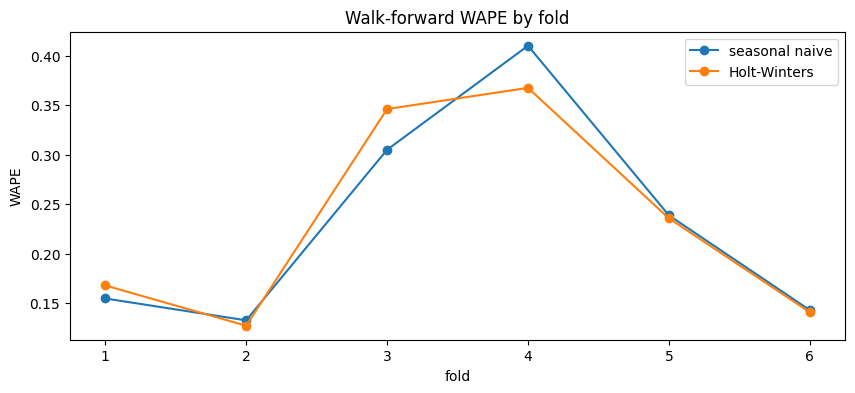

In [7]:
summary = backtest[["wape_seasonal_naive", "wape_holt_winters", "bias_seasonal_naive", "bias_holt_winters"]].mean()
print("Mean across", N_FOLDS, "folds:")
print(summary.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(backtest["fold"], backtest["wape_seasonal_naive"], marker="o", label="seasonal naive")
ax.plot(backtest["fold"], backtest["wape_holt_winters"], marker="o", label="Holt-Winters")
ax.set_xlabel("fold")
ax.set_ylabel("WAPE")
ax.set_title("Walk-forward WAPE by fold")
ax.legend()
plt.show()

## Acceptance rule

Report the model only if its walk-forward WAPE beats seasonal naive; otherwise the baseline
itself is the recommendation - also a valid, defensible result (MASTER_DOC section 14).

In [8]:
winner = "holt_winters" if summary["wape_holt_winters"] < summary["wape_seasonal_naive"] else "seasonal_naive"
lift_pct = (summary["wape_seasonal_naive"] - summary["wape_holt_winters"]) / summary["wape_seasonal_naive"] * 100

print(f"Seasonal naive mean WAPE: {summary['wape_seasonal_naive']:.4f} (bias {summary['bias_seasonal_naive']:+.2f})")
print(f"Holt-Winters   mean WAPE: {summary['wape_holt_winters']:.4f} (bias {summary['bias_holt_winters']:+.2f})")
print(f"Verdict: {winner} wins, {lift_pct:+.1f}% WAPE change vs. seasonal naive")

Seasonal naive mean WAPE: 0.2308 (bias -10.14)
Holt-Winters   mean WAPE: 0.2310 (bias +2.44)
Verdict: seasonal_naive wins, -0.1% WAPE change vs. seasonal naive


## Production forecast: next 28 days beyond the stable window

In [9]:
if winner == "holt_winters":
    final_model = ExponentialSmoothing(daily, trend="add", seasonal="add", seasonal_periods=7).fit()
    point_forecast = final_model.forecast(H).to_numpy()
    residual_pool = np.array(hw_residuals)
else:
    point_forecast = seasonal_naive_forecast(daily, H)
    residual_pool = np.concatenate([
        (daily.iloc[len(daily) - (N_FOLDS - f) * H: len(daily) - (N_FOLDS - f) * H + H].to_numpy()
         - seasonal_naive_forecast(daily.iloc[:len(daily) - (N_FOLDS - f) * H], H))
        for f in range(N_FOLDS)
    ])

lower_q, upper_q = np.percentile(residual_pool, [2.5, 97.5])
forecast_dates = pd.date_range(daily.index[-1] + pd.Timedelta(days=1), periods=H, freq="D")

forecast_df = pd.DataFrame({
    "date": forecast_dates,
    "forecast": point_forecast,
    "lower": np.maximum(point_forecast + lower_q, 0),
    "upper": point_forecast + upper_q,
})
forecast_df

,date,forecast,lower,upper
0,2018-08-23,320,210.175,437.25
1,2018-08-24,257,147.175,374.25
2,2018-08-25,198,88.175,315.25
3,2018-08-26,204,94.175,321.25
4,2018-08-27,256,146.175,373.25
5,2018-08-28,243,133.175,360.25
6,2018-08-29,187,77.175,304.25
7,2018-08-30,320,210.175,437.25
8,2018-08-31,257,147.175,374.25
9,2018-09-01,198,88.175,315.25


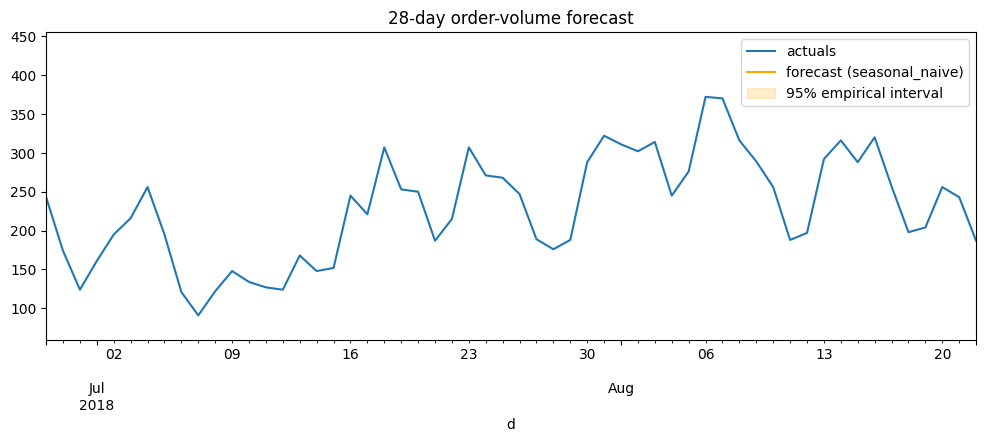

Expected next-28-day volume: 6660 orders (95% interval 3585-9943)


In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
daily.iloc[-56:].plot(ax=ax, label="actuals")
ax.plot(forecast_df["date"], forecast_df["forecast"], color="orange", label=f"forecast ({winner})")
ax.fill_between(forecast_df["date"], forecast_df["lower"], forecast_df["upper"], color="orange", alpha=0.2, label="95% empirical interval")
ax.legend()
ax.set_title("28-day order-volume forecast")
plt.show()

total_forecast = forecast_df["forecast"].sum()
total_lower = forecast_df["lower"].sum()
total_upper = forecast_df["upper"].sum()
print(f"Expected next-28-day volume: {total_forecast:.0f} orders (95% interval {total_lower:.0f}-{total_upper:.0f})")

## Export (declared side effect)

In [11]:
from pathlib import Path

Path("../data/processed").mkdir(parents=True, exist_ok=True)
forecast_df.to_csv("../data/processed/forecast_28d.csv", index=False)

with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS analytics.forecast_28d"))
    conn.execute(text("""
        CREATE TABLE analytics.forecast_28d (
            date DATE PRIMARY KEY,
            forecast NUMERIC,
            lower NUMERIC,
            upper NUMERIC
        )
    """))
forecast_df.to_sql("forecast_28d", engine, schema="analytics", if_exists="append", index=False)

logger.info(
    "Forecast exported: model=%s, wape_seasonal_naive=%.4f, wape_holt_winters=%.4f, next-28d volume=%.0f (%.0f-%.0f)",
    winner, summary["wape_seasonal_naive"], summary["wape_holt_winters"],
    total_forecast, total_lower, total_upper,
)
print("Wrote analytics.forecast_28d and data/processed/forecast_28d.csv")

2026-07-09 18:43:42,847 INFO notebooks.04_demand_forecast: Forecast exported: model=seasonal_naive, wape_seasonal_naive=0.2308, wape_holt_winters=0.2310, next-28d volume=6660 (3585-9943)


Wrote analytics.forecast_28d and data/processed/forecast_28d.csv
